# 01 — Sensing pipeline quality (RQ2)

Claim: the platform acquires a real Tobii stream at the rated rate with high validity. Evidence: achieved sampling rate, inter-sample interval, and gaze validity per session.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _lib
_lib.apply_style()
try:
    data = _lib.read_cache()
except FileNotFoundError:
    data = _lib.load_all(); _lib.write_cache(data)


In [2]:
g = data.gaze.copy()
g['leftValid'] = g['leftValidity'].eq('Valid')
g['rightValid'] = g['rightValidity'].eq('Valid')
g['anyValid'] = g['leftValid'] | g['rightValid']
valid = g.groupby('sessionKey')['anyValid'].mean().rename('gazeValidityRate')
summ = data.sessions.set_index('sessionKey')[['participant','condition','achievedHz',
    'calibrationAccuracyDeg','calibrationPrecisionDeg','durationSec','nGazeSamples']].join(valid)
summ = summ.reset_index(drop=True)
_lib.save_table(summ, 'sensing_summary')
summ.round(3)

,participant,condition,achievedHz,calibrationAccuracyDeg,calibrationPrecisionDeg,durationSec,nGazeSamples,gazeValidityRate
0,P1,with,89.98,0.619,0.330,185.521,16664,0.962
1,P2,with,90.06,0.685,0.233,252.218,22688,0.980
2,P3,with,89.41,0.360,0.146,171.483,15305,0.925
3,P4,with,90.00,0.296,0.088,224.043,20136,0.952
4,P1,without,89.90,0.471,0.177,475.089,42683,0.939
5,P2,without,89.84,0.445,0.177,123.420,11063,0.976
6,P3,without,89.87,0.381,0.160,385.589,34624,0.950
7,P4,without,90.02,0.328,0.083,141.378,12697,0.960


### Achieved sampling rate and validity per session

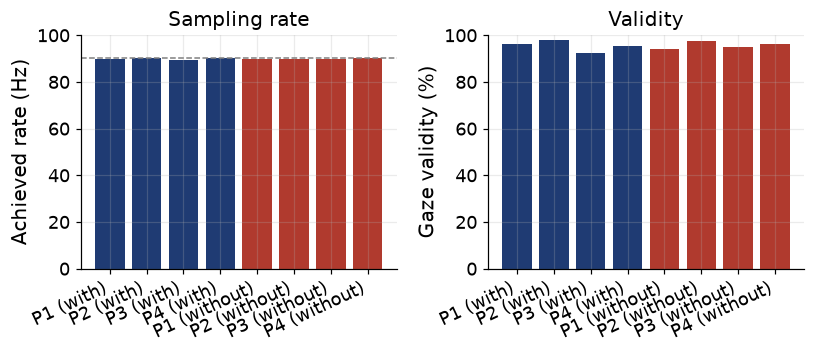

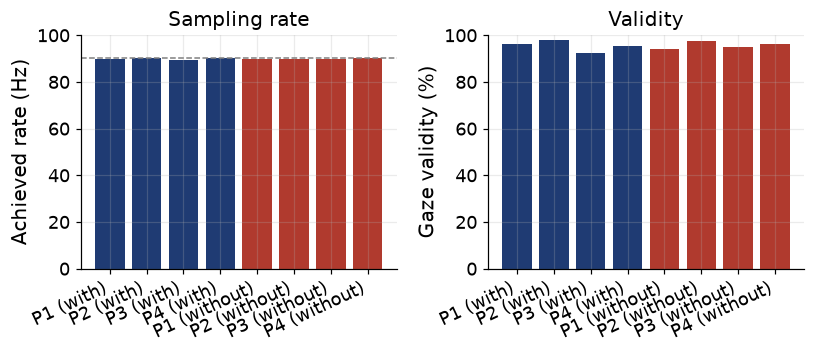

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.4))
order = summ.sort_values(['condition','participant'])
labels = order['participant'] + ' (' + order['condition'] + ')'
colors = [_lib.CONDITION_COLORS[c] for c in order['condition']]
axes[0].bar(labels, order['achievedHz'], color=colors)
axes[0].axhline(90, ls='--', c='gray', lw=1)
axes[0].set_ylabel('Achieved rate (Hz)'); axes[0].set_title('Sampling rate'); axes[0].set_ylim(0, 100)
axes[1].bar(labels, order['gazeValidityRate']*100, color=colors)
axes[1].set_ylabel('Gaze validity (%)'); axes[1].set_title('Validity'); axes[1].set_ylim(0, 100)
for ax in axes:
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha='right')
fig.tight_layout(); _lib.save_fig(fig, '01_sensing_rate_validity'); fig

### Inter-sample interval (device clock)
Tight clustering near the nominal period confirms a steady real-time stream.

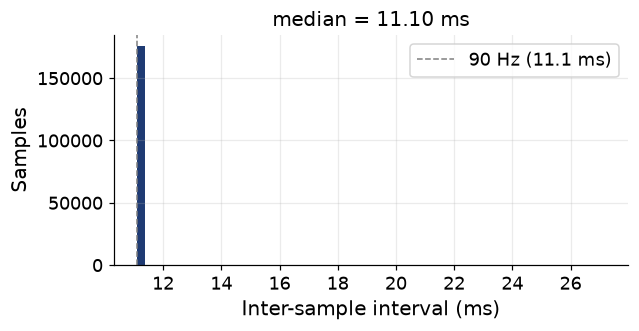

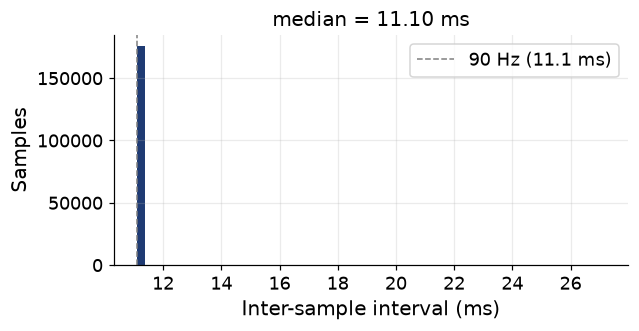

In [4]:
iv = data.gaze.sort_values(['sessionKey','sequenceNumber']).copy()
iv['intervalMs'] = iv.groupby('sessionKey')['deviceTimeStampUs'].diff() / 1000.0
vals = iv['intervalMs'].dropna()
vals = vals[(vals > 0) & (vals < 30)]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(vals, bins=60, color=_lib.CONDITION_COLORS['with'])
ax.axvline(1000/90, ls='--', c='gray', lw=1, label='90 Hz (11.1 ms)')
ax.set_xlabel('Inter-sample interval (ms)'); ax.set_ylabel('Samples'); ax.legend()
ax.set_title(f'median = {vals.median():.2f} ms')
fig.tight_layout(); _lib.save_fig(fig, '01_inter_sample_interval'); fig